<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Backpropagation/Backpropagation(Regrassion).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]], columns = ['cgpa', 'profile_score', 'lpa'])

In [ ]:
df

,cgpa,profile_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [ ]:
def initialize_parameters(layer_dims):

  np.random.seed(3)
  parameters = {}
  L = len(layer_dims)

  for l in range(1, L):

    parameters['W' + str(l)] = np.ones((layer_dims[l-1], layer_dims[l]))*0.1
    parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))


  return parameters

In [ ]:
initialized_parameters([2,2,1])['W1']

array([[0.1, 0.1],
       [0.1, 0.1]])

In [ ]:
W = np.array([[1, 2, 3],
              [4, 5, 6]])
print(W.T)

[[1 4]
 [2 5]
 [3 6]]


In [ ]:
len(initialized_parameters([2,2,1]))

4

In [ ]:
def linear_forward(A_prev, W, b):

  Z = np.dot(W.T, A_prev) + b

  return Z

In [ ]:
def L_layer_forward(X, parameters):

  A = X
  L = len(parameters) // 2

  for i in range(1, L+1):
    A_prev = A
    Wi = parameters['W' + str(i)]
    bi = parameters['b' + str(i)]

    print('A'+str(i-1) + ":" , A_prev)
    print('W'+str(i) + ":" , Wi)
    print('b'+str(i) + ":" , bi)

    print("-"*50)

    A = linear_forword(A_prev, Wi, bi)
    print('A'+str(i) + ":" , A)
    print("-"*50)

  return A, A_prev


In [ ]:
X = df[['cgpa', 'profile_score']].values[0].reshape(2,1)
y = df[['lpa']].values[0][0]

In [ ]:
X = df[['cgpa', 'profile_score']].values[0].reshape(2,1)
y = df[['lpa']].values[0][0]

parameters = initialized_parameters([2,2,1])

y_hat, A1 = L_layer_forward(X, parameters)


A0: [[8]
 [8]]
W1: [[0.1 0.1]
 [0.1 0.1]]
b1: [[0.]
 [0.]]
--------------------------------------------------
A1: [[1.6]
 [1.6]]
--------------------------------------------------
A1: [[1.6]
 [1.6]]
W2: [[0.1]
 [0.1]]
b2: [[0.]]
--------------------------------------------------
A2: [[0.32]]
--------------------------------------------------


In [ ]:
print(y_hat)
print(A1)

[[0.32]]
[[1.6]
 [1.6]]


In [ ]:
def update_parameters(parameters,y,y_hat,A1,X):
  parameters['W2'][0][0] = parameters['W2'][0][0] + (0.001 * 2 * (y - y_hat)*A1[0][0])
  parameters['W2'][1][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat)*A1[1][0])
  parameters['b2'][0][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat))

  parameters['W1'][0][0] = parameters['W1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[0][0])
  parameters['W1'][0][1] = parameters['W1'][0][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[1][0])
  parameters['b1'][0][0] = parameters['b1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0])

  parameters['W1'][1][0] = parameters['W1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[0][0])
  parameters['W1'][1][1] = parameters['W1'][1][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[1][0])
  parameters['b1'][1][0] = parameters['b1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0])

In [ ]:
update_parameters(parameters, y, y_hat[0][0], A1, X)

In [ ]:
parameters

{'W1': array([[0.10658137, 0.10658137],
        [0.10658137, 0.10658137]]),
 'b1': array([[0.00082267],
        [0.00082267]]),
 'W2': array([[0.111776],
        [0.111776]]),
 'b2': array([[0.119136]])}

In [ ]:
# df[['lpa']].values[1][0]

In [ ]:
#2nd row
X = df[['cgpa', 'profile_score']].values[1].reshape(2,1)
y = df[['lpa']].values[3][0]

y_hat, A1 = L_layer_forward(X, parameters)
update_parameters(parameters, y, y_hat[0][0], A1, X)
parameters

A0: [[7]
 [9]]
W1: [[0.10658137 0.10658137]
 [0.10658137 0.10658137]]
b1: [[0.00082267]
 [0.00082267]]
--------------------------------------------------
A1: [[1.70612461]
 [1.70612461]]
--------------------------------------------------
A1: [[1.70612461]
 [1.70612461]]
W2: [[0.111776]
 [0.111776]]
b2: [[0.119136]]
--------------------------------------------------
A2: [[0.50054357]]
--------------------------------------------------


{'W1': array([[0.11877014, 0.12225265],
        [0.11877014, 0.12225265]]),
 'b1': array([[0.00256392],
        [0.00256392]]),
 'W2': array([[0.13395377],
        [0.13395377]]),
 'b2': array([[0.14695268]])}

In [ ]:
#3rd row
X = df[['cgpa', 'profile_score']].values[2].reshape(2,1)
y = df[['lpa']].values[2][0]



y_hat, A1 = L_layer_forward(X, parameters)
update_parameters(parameters, y, y_hat[0][0], A1, X)
parameters

A0: [[ 6]
 [10]]
W1: [[0.11877014 0.12225265]
 [0.11877014 0.12225265]]
b1: [[0.00256392]
 [0.00256392]]
--------------------------------------------------
A1: [[1.90288623]
 [1.95860634]]
--------------------------------------------------
A1: [[1.90288623]
 [1.95860634]]
W2: [[0.13395377]
 [0.13395377]]
b2: [[0.14695268]]
--------------------------------------------------
A2: [[0.66421415]]
--------------------------------------------------


{'W1': array([[0.12864736, 0.13871468],
        [0.12868543, 0.13877813]]),
 'b1': array([[0.00421013],
        [0.00421647]]),
 'W2': array([[0.15426055],
        [0.15485517]]),
 'b2': array([[0.16552674]])}

In [ ]:
#4th row
X = df[['cgpa', 'profile_score']].values[3].reshape(2,1)
y = df[['lpa']].values[3][0]



y_hat, A1 = L_layer_forward(X, parameters)
update_parameters(parameters, y, y_hat[0][0], A1, X)
parameters

A0: [[ 5]
 [12]]
W1: [[0.12864736 0.13871468]
 [0.12868543 0.13877813]]
b1: [[0.00421013]
 [0.00421647]]
--------------------------------------------------
A1: [[2.19167212]
 [2.36312743]]
--------------------------------------------------
A1: [[2.19167212]
 [2.36312743]]
W2: [[0.15426055]
 [0.15485517]]
b2: [[0.16552674]]
--------------------------------------------------
A2: [[0.8695578]]
--------------------------------------------------


{'W1': array([[0.13975158, 0.1653648 ],
        [0.13995498, 0.16582504]]),
 'b1': array([[0.00643097],
        [0.00647038]]),
 'W2': array([[0.18113239],
        [0.18382921]]),
 'b2': array([[0.19609009]])}

In [ ]:
#epoch implementation

parameters  = initialized_parameters([2,2,1])
epochs = 5

for i in range(epochs):
  Loss = []

  for j in range(df.shape[0]):

    X = df[['cgpa', 'profile_score']].values[j].reshape(2,1)
    y = df[['lpa']].values[j][0]

    # Parameter initialization

    y_hat, A1 = L_layer_forward(X, parameters)
    update_parameters(parameters, y, y_hat[0][0], A1, X)
    Loss.append((y-y_hat)**2)

    print('Epoch - ', i+1, 'Loss - ', np.array(Loss).mean())

parameters

A0: [[8]
 [8]]
W1: [[0.1 0.1]
 [0.1 0.1]]
b1: [[0.]
 [0.]]
--------------------------------------------------
A1: [[1.6]
 [1.6]]
--------------------------------------------------
A1: [[1.6]
 [1.6]]
W2: [[0.1]
 [0.1]]
b2: [[0.]]
--------------------------------------------------
A2: [[0.32]]
--------------------------------------------------
Epoch -  1 Loss -  13.542399999999997
A0: [[7]
 [9]]
W1: [[0.10658137 0.10658137]
 [0.10658137 0.10658137]]
b1: [[0.00082267]
 [0.00082267]]
--------------------------------------------------
A1: [[1.70612461]
 [1.70612461]]
--------------------------------------------------
A1: [[1.70612461]
 [1.70612461]]
W2: [[0.111776]
 [0.111776]]
b2: [[0.119136]]
--------------------------------------------------
A2: [[0.50054357]]
--------------------------------------------------
Epoch -  1 Loss -  16.89375409265402
A0: [[ 6]
 [10]]
W1: [[0.11458955 0.1168776 ]
 [0.11458955 0.1168776 ]]
b1: [[0.0019667]
 [0.0019667]]
----------------------------------------

{'W1': array([[0.26507636, 0.38558861],
        [0.27800387, 0.40980287]]),
 'b1': array([[0.02749056],
        [0.02974394]]),
 'W2': array([[0.41165744],
        [0.48302736]]),
 'b2': array([[0.48646246]])}

In [55]:
from sklearn.datasets import make_classification
import numpy as np

In [32]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=15)

In [33]:
X.shape

(100, 2)

In [34]:
y.shape

(100,)

In [35]:
# X[:, 0]
# X[:, 1]

In [36]:
import matplotlib.pyplot as plt

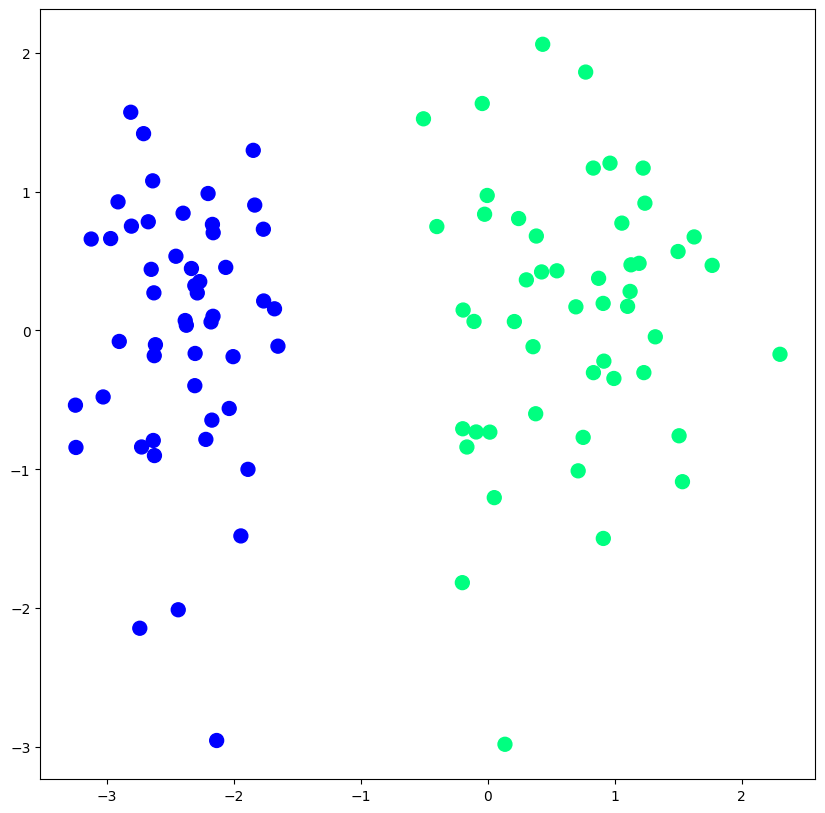

In [37]:
plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap = 'winter', s = 100)
plt.show()

In [45]:
def perceptron(X, y):

  w1 = w2 = b = 1
  lr = 0.1

  for j in range(1000):
    for i in range(X.shape[0]):

      #check condition
      z= w1*X[i][0] + w2*X[i][1] + b

      if z*y[i] < 0:
        w1 = w1 + lr*y[i]*X[i][0]
        w2 = w2 + lr*y[i]*X[i][1]
        b = b + lr * y[i]

  return w1, w2, b

In [49]:
w1, w2, b = perceptron(X, y)

In [50]:
b

np.float64(1.3000000000000003)

In [52]:
m = -(w1/w2)
c = -(b/w2)
print(m, c)

-4.531321834268464 -5.851870329508209


In [58]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input+c

(-3.0, 3.0)

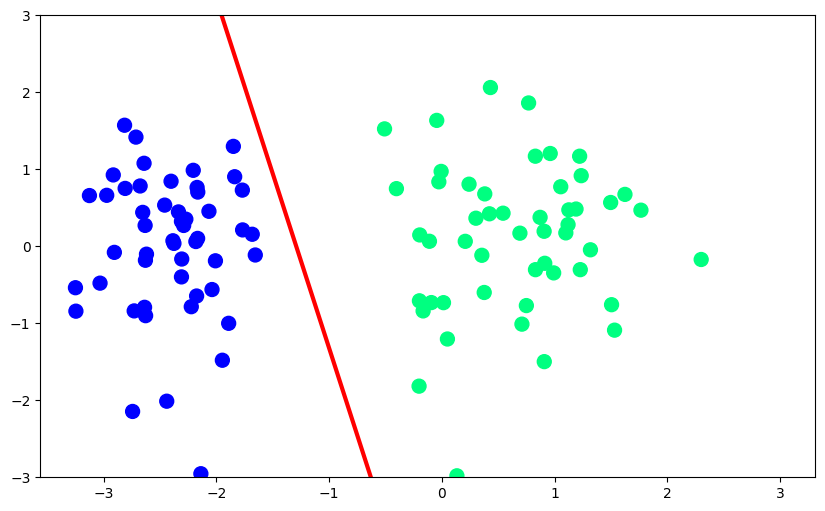

In [60]:
plt.figure(figsize = (10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap = 'winter', s = 100)
plt.ylim(-3,3)